In [2]:
# uncomment this line if you need to install pyphyschemtools
# (remove "# " - don't forget to remove the empty space)
# 1. Force uninstall the old version completely
# !pip uninstall pyNanoMatBuilder -y

# 2. Install the new version with flags that bypass all caches and force a refresh
# !pip install --index-url https://test.pypi.org/simple/ pyNanoMatBuilder==0.9.0 --no-cache-dir --no-deps

# Optional: only necessary if you want to visualize 3D structures directly within the notebook.
# !pip install pyphyschemtools

<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyNanoMatBuilder/blob/main/pyNMB-examples.ipynb)

</div>

pyNanoMatBuilder: parallelism set to 4 threads.



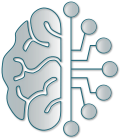

**Environment initialized:** Friday 12 June 2026, 09:31:11 on insa-12842  
<span style='color: #007a7a; font-weight: bold;'>[OK] Parallel computing ENABLED (4 threads)</span>

pyNMB.__version__='0.16.0'


In [3]:
# # development purpose only. Comment these 2 lines on Google Colab
%load_ext autoreload
%autoreload 2
#------------------------------

##################
# Initialization #
##################
import pyNanoMatBuilder as pyNMB
pyNMB.set_threads(4)
pyNMB.init()
%matplotlib inline
print(f"{pyNMB.__version__=}")

from pyNanoMatBuilder import utils as pyNMBu
import pyNanoMatBuilder as pyNMB

# Tutorials

## Evaluating relevant sizes to fit an experimental SAXS signal

### Context and workflow

<div class="intro">

A SAXS spectrum measured on a nanoparticle sample is never the signal of a single, perfectly monodisperse object. It is the weighted sum of contributions from particles of different sizes, distributed according to a size distribution (Gaussian, Schulz, etc.).
The goal of this section is to identify which discrete sizes are most relevant to reproduce and interpret an experimental SAXS spectrum, as a first step toward a full polydispersity-aware simulation. The overall workflow is:

1. Identify some characteristic sizes from the experimental distribution
2. Build the corresponding atomic structures with pyNanoMatBuilder and optimize them
3. Compute individual SAXS spectra for each structure, then sum them with the appropriate weights to reproduce the experimental spectrum

In this example, we work with **silver icosahedra** from the study of xxx et al. From SAXS experiments, after volumetric correction between spheres and icosahedra, the following parameters can be inferred:

- *&mu;*(exp) = 2.60 nm
- %PD = 11%

The size distribution is modeled here with a Schulz distribution, which is better suited than a Gaussian for SAXS/SANS experiments as it accounts for the natural asymmetry of nanoparticle size distributions (skewed toward larger sizes).
</div>

### Step 1. Identify some characteristic sizes from the experimental distribution

<div class="intro">

**(a) Theoretical Schulz distribution from SAXS fit**

From the experimental parameters, we build the theoretical Schulz distribution and identify the characteristic sizes at μ ± nσ. These sizes will serve as references for the atomic structures to be built and simulated in the following steps. The table shows, for each characteristic size, its relative weight in the distribution. Sizes close to μ carry the highest weight, while those beyond ±3σ contribute very little and can generally be neglected.

The next step will be to identify which nOrder values in pyNanoMatBuilder produce structures whose geometry, after optimization, best matches these target diameters. If perfect, defect-free icosahedra do not land close enough to the target sizes, structures with incomplete outer shells (surface peeling) will be considered as intermediate sizes between two consecutive magic numbers.
</div>

  μ-4σ                                D=1.4560 nm → bin [1.3130, 1.5990]  (1 structure in bin, intra-bin share=1.000)
  μ-3σ                                D=1.7420 nm → bin [1.5990, 1.8850]  (1 structure in bin, intra-bin share=1.000)
  μ-2σ                                D=2.0280 nm → bin [1.8850, 2.1710]  (1 structure in bin, intra-bin share=1.000)
  μ-σ                                 D=2.3140 nm → bin [2.1710, 2.4570]  (1 structure in bin, intra-bin share=1.000)
  μ                                   D=2.6000 nm → bin [2.4570, 2.7430]  (1 structure in bin, intra-bin share=1.000)
  μ+σ                                 D=2.8860 nm → bin [2.7430, 3.0290]  (1 structure in bin, intra-bin share=1.000)
  μ+2σ                                D=3.1720 nm → bin [3.0290, 3.3150]  (1 structure in bin, intra-bin share=1.000)
  μ+3σ                                D=3.4580 nm → bin [3.3150, 3.6010]  (1 structure in bin, intra-bin share=1.000)
  μ+4σ                                D=3.7440 nm → bin 

Label    | Diameter (nm)   | Ratio/Peak   | Est. Count   | Norm. (dist)   | Norm. (1)   
----------------------------------------------------------------------------------------
μ-4σ     |         1.46 nm |      0.000   |          0   |       0.0000   |     0.0000
μ-3σ     |         1.74 nm |      0.003   |          3   |       0.0031   |     0.0031
μ-2σ     |         2.03 nm |      0.057   |         57   |       0.0570   |     0.0570
μ-σ      |         2.31 nm |      0.258   |        258   |       0.2582   |     0.2582
μ        |         2.60 nm |      0.383   |        383   |       0.3829   |     0.3829
μ+σ      |         2.89 nm |      0.227   |        227   |       0.2268   |     0.2269
μ+2σ     |         3.17 nm |      0.062   |         62   |       0.0623   |     0.0623
μ+3σ     |         3.46 nm |      0.009   |          9   |       0.0089   |     0.0089
μ+4σ     |         3.74 nm |      0.001   |          1   |       0.0007   |     0.0007
---------------------------------------

  μ-4σ                                D=1.4560 nm → bin [1.3130, 1.5990]  (1 structure in bin, intra-bin share=1.000)
  μ-3σ                                D=1.7420 nm → bin [1.5990, 1.8850]  (1 structure in bin, intra-bin share=1.000)
  μ-2σ                                D=2.0280 nm → bin [1.8850, 2.1710]  (1 structure in bin, intra-bin share=1.000)
  μ-σ                                 D=2.3140 nm → bin [2.1710, 2.4570]  (1 structure in bin, intra-bin share=1.000)
  μ                                   D=2.6000 nm → bin [2.4570, 2.7430]  (1 structure in bin, intra-bin share=1.000)
  μ+σ                                 D=2.8860 nm → bin [2.7430, 3.0290]  (1 structure in bin, intra-bin share=1.000)
  μ+2σ                                D=3.1720 nm → bin [3.0290, 3.3150]  (1 structure in bin, intra-bin share=1.000)
  μ+3σ                                D=3.4580 nm → bin [3.3150, 3.6010]  (1 structure in bin, intra-bin share=1.000)
  μ+4σ                                D=3.7440 nm → bin 

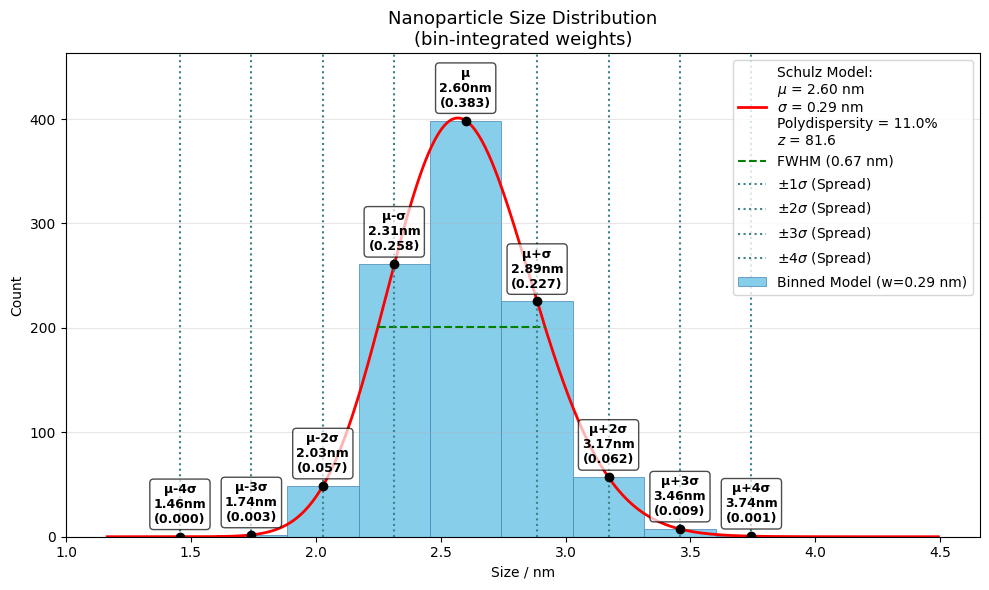

In [2]:
nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=2.60, pd_pct=11, model="schulz")
nd.print_specific_proportions(nd.representative_sizes, nd.representative_labels)
nd.plot(highlight_sizes=[nd.representative_sizes, nd.representative_labels])

<div class="intro">

**(b) Convert the SAXS diameter to a core-to-core diameter**

The diameter measured by SAXS includes the electron density cloud around each surface atom. To compare it with the core-to-core dimensions produced by pyNanoMatBuilder, we subtract one atomic radius on each side:

$$D_\text{core}=D_\text{SAXS}−2×r_\text{Ag}$$

We first inspect the available atomic radii for silver:
</div>

In [3]:
Ag = pyNMBu.print_atomic_radii("Ag")
print()
print(Ag.metallic_radius)
print(Ag.get_ionic_radii(charge=+1, coordination='VI'))

Atomic radii for Silver (Ag)
──────────────────────────────────────────────────
  metallic_radius      :   134 pm  =  1.3400 Å
  covalent_radius      :   128 pm  =  1.2800 Å
  vdw_radius           :   211 pm  =  2.1100 Å
  atomic_radius        :   160 pm  =  1.6000 Å

  Ionic radii
  ──────────────────────────────────────────────
  Charge   Coord.   Spin         Radius (pm)    Radius (Å)
  ──────────────────────────────────────────────
      +1   II       n/a                67 pm   0.6700 Å
      +1   IV       n/a               100 pm   1.0000 Å
      +1   IVSQ     n/a               102 pm   1.0200 Å
      +1   V        n/a               109 pm   1.0900 Å
      +1   VI       n/a               115 pm   1.1500 Å
      +1   VII      n/a               122 pm   1.2200 Å
      +1   VIII     n/a               128 pm   1.2800 Å
      +2   IVSQ     n/a                79 pm   0.7900 Å
      +2   VI       n/a                94 pm   0.9400 Å
      +3   IVSQ     n/a                67 pm   0.6700 Å


<div class="intro">

For metallic nanoparticles, the metallic radius is the most physically meaningful choice — it reflects the actual atomic size in a crystalline metallic environment, and is consistent with the nearest-neighbor distance used internally by pyNanoMatBuilder (*Rnn* = 2 × *r*<sub>metallic</sub>).

We then rebuild the distribution using the corrected mean diameter — all sizes are now expressed as core-to-core distances, directly comparable to pyNanoMatBuilder output:
</div>

  μ-4σ                                D=1.3059 nm → bin [1.1777, 1.4342]  (1 structure in bin, intra-bin share=1.000)
  μ-3σ                                D=1.5624 nm → bin [1.4342, 1.6907]  (1 structure in bin, intra-bin share=1.000)
  μ-2σ                                D=1.8190 nm → bin [1.6907, 1.9472]  (1 structure in bin, intra-bin share=1.000)
  μ-σ                                 D=2.0755 nm → bin [1.9472, 2.2037]  (1 structure in bin, intra-bin share=1.000)
  μ                                   D=2.3320 nm → bin [2.2037, 2.4603]  (1 structure in bin, intra-bin share=1.000)
  μ+σ                                 D=2.5885 nm → bin [2.4603, 2.7168]  (1 structure in bin, intra-bin share=1.000)
  μ+2σ                                D=2.8450 nm → bin [2.7168, 2.9733]  (1 structure in bin, intra-bin share=1.000)
  μ+3σ                                D=3.1016 nm → bin [2.9733, 3.2298]  (1 structure in bin, intra-bin share=1.000)
  μ+4σ                                D=3.3581 nm → bin 

Label    | Diameter (nm)   | Ratio/Peak   | Est. Count   | Norm. (dist)   | Norm. (1)   
----------------------------------------------------------------------------------------
μ-4σ     |         1.31 nm |      0.000   |          0   |       0.0000   |     0.0000
μ-3σ     |         1.56 nm |      0.003   |          3   |       0.0031   |     0.0031
μ-2σ     |         1.82 nm |      0.057   |         57   |       0.0570   |     0.0570
μ-σ      |         2.08 nm |      0.258   |        258   |       0.2582   |     0.2582
μ        |         2.33 nm |      0.383   |        383   |       0.3829   |     0.3829
μ+σ      |         2.59 nm |      0.227   |        227   |       0.2268   |     0.2269
μ+2σ     |         2.85 nm |      0.062   |         62   |       0.0623   |     0.0623
μ+3σ     |         3.10 nm |      0.009   |          9   |       0.0089   |     0.0089
μ+4σ     |         3.36 nm |      0.001   |          1   |       0.0007   |     0.0007
---------------------------------------

  μ-4σ                                D=1.3059 nm → bin [1.1777, 1.4342]  (1 structure in bin, intra-bin share=1.000)
  μ-3σ                                D=1.5624 nm → bin [1.4342, 1.6907]  (1 structure in bin, intra-bin share=1.000)
  μ-2σ                                D=1.8190 nm → bin [1.6907, 1.9472]  (1 structure in bin, intra-bin share=1.000)
  μ-σ                                 D=2.0755 nm → bin [1.9472, 2.2037]  (1 structure in bin, intra-bin share=1.000)
  μ                                   D=2.3320 nm → bin [2.2037, 2.4603]  (1 structure in bin, intra-bin share=1.000)
  μ+σ                                 D=2.5885 nm → bin [2.4603, 2.7168]  (1 structure in bin, intra-bin share=1.000)
  μ+2σ                                D=2.8450 nm → bin [2.7168, 2.9733]  (1 structure in bin, intra-bin share=1.000)
  μ+3σ                                D=3.1016 nm → bin [2.9733, 3.2298]  (1 structure in bin, intra-bin share=1.000)
  μ+4σ                                D=3.3581 nm → bin 

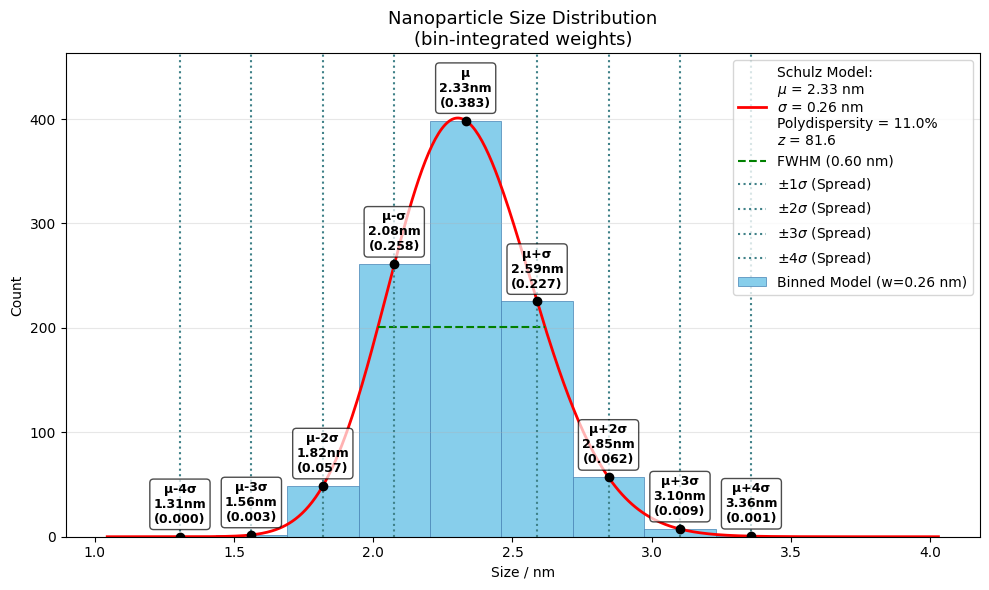

In [4]:
mu_core = 2.60-2*Ag.metallic_radius/10

nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=mu_core, pd_pct=11, model="schulz")
nd.print_specific_proportions(nd.representative_sizes, nd.representative_labels)
nd.plot(highlight_sizes=[nd.representative_sizes,nd.representative_labels])

<div class="rqE">

These corrected diameters are the actual target sizes to match with pyNanoMatBuilder structures in Step 2.
</div>

### Step 2. Build the corresponding atomic structures with pyNanoMatBuilder and optimize them

#### Find the nOrder value that yields an icosahedral NP with diameter close to *μ*

<div class="intro">
The first step is to identify which nOrder values produce icosahedra whose diameter, after geometry optimization, falls close to the target sizes identified in Step 1. This is done by a manual trial-and-error exploration: we build a few icosahedra with increasing nOrder, optimize their geometry, and compare their actual dimensions to *μ* − *σ*, *μ*, and *μ* + *σ*.
Magic-number icosahedra being discrete objects, there is no guarantee that a perfect, defect-free structure will land exactly on a target size. Between two consecutive nOrder values, intermediate sizes can be reached by peeling the outermost atomic layer, removing atoms with the lowest coordination number. This gives access to a continuous range of sizes between two magic numbers.
</div>

Regular icosahedron with 5 shell(s) and Rnn = 2.7


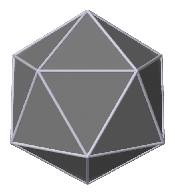

element =  Ag
number of vertices =  12
number of edges =  30
number of faces =  20
phi =  1.618033988749895
intershell factor = 1.05
nearest neighbour distance = 2.70 Å
intershell distance = 2.57 Å
edge length = 1.35 nm
radius after volume = 1.09 nm
radius of the circumscribed sphere = 1.28 nm
radius of the inscribed sphere = 1.02 nm
area = 15.8 nm2
volume = 5.4 nm3
number of atoms per shell =  [1, 12, 42, 92, 162, 252]
cumulative number of atoms per shell =  [1, 13, 55, 147, 309, 561]
total number of atoms =  561
Dual polyhedron: dodecahedron


Total number of atoms = 561
[1, 12, 42, 92, 162, 252]
Duration : 00:00:00 006ms


Moments of inertia = 3483379.35 3483379.35 3483379.35 amu.Å2
Moments of inertia / M = 57.56 57.56 57.56 amu.Å2
Moments of inertia with mass=1/M = 57.56 57.56 57.56 Å2


 Principal Moments : I1=57.56, I2=57.56, I3=57.56
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.9 nm


...

Found:
  - 252 vertices
  - 500 simplices
  - Volume: 6.87 nm³
  - Area: 18.32 nm²
Duration : 00:00:00 002ms


252 atoms lie in the plane(s)
Duration : 00:00:00 007ms


Diameter of the circumscribed sphere: 27.34 Å
Diameter of the inscribed sphere: 22.36 Å


  - Dimensions (Å): 27.34 x 27.34 x 27.34
  - Volume: 10.70 nm³
  - Surface: 23.48 nm²
  - Asphericity: 1.00
  - Max Radius found: 1.367 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {13.670655 0.000000 0.000000} {-0.000000 12.250192 6.067916} {0.000000 6.067916 -12.250192}; ellipsoid ID optimized_structure_el CENTER {-0.000 0.000 -0.000}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:02 215ms


initial  optimized
method     mode                        
feret      —          2.3505     2.5052
rg         —          2.3992     2.5966
rms        vertices   2.5679     2.7341
           all        2.5679     2.7341
           planes     2.5679     2.4922
volume     vertices   2.5679     2.7341
           all        2.5679     2.7341
           planes     2.5679     2.4922
arithmetic vertices   2.5679     2.7341
           all        2.5679     2.7341
           planes     2.5679     2.4922
surface    vertices   2.5679     2.7341
           all        2.5679     2.7341
           planes     2.5679     2.4922

In [5]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

ico = pNP.regIco("Ag",
                 2.7,
                 5,
                 skipSymmetryAnalyzis=True,
                 noOutput=False
                )

pyNMBu.write(f"coords/disp/ico.xyz", ico.NP)
pyNMBu.write(f"coords/disp/ico_cs.xyz", ico.NPcs)
pyNMBu.write(f"coords/disp/ico.script", ico.jMolCS)
ico.optimize()
pyNMBu.write(f"coords/disp/ico_opt.xyz", ico.NP_opt)
pyNMBu.write(f"coords/disp/ico_cs_opt.xyz", ico.NPcs_opt)
d = pyNMBu.compare_effective_diameters(ico, n_feret=5000)

####  Bracketing around the 4-shell icosahedron

<div class="intro">

We will now systematically build and optimize icosahedra from 2 to 7 shells to bracket structures around the target size, and to evaluate what would be their weight in a weighted sum of individual SAXS signals.
</div>

In [6]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the number of shells
nshells=range(2,8)
D = []
labels = []
for nshell in nshells:
    name=f"ico_{nshell:02d}"
    pyNMBu.centerTitle(name)
    ico = pNP.regIco("Ag",
                     2.7,
                     nshell,
                     skipSymmetryAnalyzis=True,
                     noOutput=True
                    )
    
    pyNMBu.write(f"coords/disp/{name}.xyz", ico.NP)
    ico.optimize(noOutput=True)
    d = ico.effective_diameter(structure='optimized', mode='vertices')/10  # Å > nm
    D.append(d)
    print(f"nOrder {nshell:<2}. nAtoms: {ico.nAtoms:<5}. D = {d: .2f} nm\nRg = {ico.Rg_opt:.2f} nm")
    pyNMBu.write(f"coords/disp/{name}_opt.xyz", ico.NP_opt)
    labels.append(f"{nshell:<2} sh.\nRg={ico.Rg_opt:.2f} nm")

print(D)
print(labels)

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:00:02       31.212727       2.4888
BFGSLineSearch:    1[  1] 21:00:02       23.954186       4.5237
BFGSLineSearch:    2[  2] 21:00:02       17.789497       0.8437
BFGSLineSearch:    3[  3] 21:00:02       17.535119       0.3591
BFGSLineSearch:    4[  4] 21:00:02       17.474512       0.0457
Duration : 00:00:00 056ms
nOrder 2 . nAtoms: 55   . D =  1.09 nm
Rg = 0.45 nm


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:00:02       80.141346       2.7001
BFGSLineSearch:    1[  1] 21:00:02       57.738340       2.4110
BFGSLineSearch:    2[  2] 21:00:02       42.233074       3.3130
BFGSLineSearch:    3[  3] 21:00:02       35.231519       0.4843
BFGSLineSearch:    4[  4] 21:00:02       34.050496       0.2071
BFGSLineSearch:    5[  5] 21:00:03       33.905959       0.0507
Duration : 00:00:00 160ms
nOrder 3 . nAtoms: 147  . D =  1.63 nm
Rg = 0.64 nm


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:00:03      165.228073       2.7018
BFGSLineSearch:    1[  1] 21:00:03      121.085618       2.4504
BFGSLineSearch:    2[  2] 21:00:03      100.871151       5.6999
BFGSLineSearch:    3[  3] 21:00:03       81.222434       7.5421
BFGSLineSearch:    4[  4] 21:00:03       62.139671       2.1306
BFGSLineSearch:    5[  5] 21:00:03       57.152578       0.9668
BFGSLineSearch:    6[  6] 21:00:03       56.249104       0.4101
BFGSLineSearch:    7[  7] 21:00:03       56.104868       0.1665
BFGSLineSearch:    8[  8] 21:00:03       56.065677       0.0364
Duration : 00:00:01 620ms
nOrder 4 . nAtoms: 309  . D =  2.19 nm
Rg = 0.82 nm


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:00:03      296.684774       2.7033
BFGSLineSearch:    1[  1] 21:00:03      223.571439       2.4488
BFGSLineSearch:    2[  2] 21:00:04      180.073203       3.4268
BFGSLineSearch:    3[  3] 21:00:04      146.425260       6.4171
BFGSLineSearch:    4[  4] 21:00:04      116.170249       2.6919
BFGSLineSearch:    5[  5] 21:00:04       95.276811       1.0123
BFGSLineSearch:    6[  6] 21:00:05       86.482426       0.4221
BFGSLineSearch:    7[  7] 21:00:05       84.660308       0.2799
BFGSLineSearch:    8[  8] 21:00:05       84.321348       0.1270
BFGSLineSearch:    9[  9] 21:00:05       84.236133       0.0725
Duration : 00:00:02 190ms
nOrder 5 . nAtoms: 561  . D =  2.73 nm
Rg = 1.01 nm


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:00:06      484.723319       2.7048
BFGSLineSearch:    1[  1] 21:00:06      375.412216       2.4474
BFGSLineSearch:    2[  2] 21:00:07      303.636724       3.3878
BFGSLineSearch:    3[  3] 21:00:07      265.696356       6.2040
BFGSLineSearch:    4[  4] 21:00:08      225.184760       4.2587
BFGSLineSearch:    5[  6] 21:00:09      167.655936       7.7850
BFGSLineSearch:    6[  7] 21:00:10      139.057921       1.2763
BFGSLineSearch:    7[  8] 21:00:11      124.106795       0.5791
BFGSLineSearch:    8[  9] 21:00:11      119.492165       0.2242
BFGSLineSearch:    9[ 10] 21:00:12      118.827505       0.1363
BFGSLineSearch:   10[ 12] 21:00:13      118.562159       0.1124
BFGSLineSearch:   11[ 14] 21:00:14      118.395874       0.0625
Duration : 00:00:09 633ms
nOrder 6 . nAtoms: 923  . D =  3.29 nm
Rg = 1.19 nm


                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 21:00:14      739.555577       2.7048
BFGSLineSearch:    1[  1] 21:00:14      586.795441       2.4474
BFGSLineSearch:    2[  2] 21:00:17      479.571607       3.3325
BFGSLineSearch:    3[  3] 21:00:20      411.765182       5.5923
BFGSLineSearch:    4[  4] 21:00:23      367.592597       6.9603
BFGSLineSearch:    5[  6] 21:00:26      292.672000       6.5321
BFGSLineSearch:    6[  8] 21:00:29      209.206249       2.3464
BFGSLineSearch:    7[  9] 21:00:31      183.150540       1.1682
BFGSLineSearch:    8[ 10] 21:00:34      166.640868       0.4620
BFGSLineSearch:    9[ 11] 21:00:37      160.543622       0.3444
BFGSLineSearch:   10[ 12] 21:00:40      159.865297       0.2085
BFGSLineSearch:   11[ 14] 21:00:43      159.307529       0.1971
BFGSLineSearch:   12[ 16] 21:00:46      159.037614       0.1165
BFGSLineSearch:   13[ 18] 21:00:48      158.867103       0.1239
BFGSLineSearch:   14[ 19] 21:00:51     

  2  sh. Rg=0.45 nm                   D=1.0864 nm → bin [0.9211, 1.1777]  (1 structure in bin, intra-bin share=1.000)
  3  sh. Rg=0.64 nm                   D=1.6341 nm → bin [1.6907, 1.9472]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [1.4342, 1.6907] → [1.6907, 1.9472] (rel_pos=0.78 > 0.75, right neighbor was empty)
  4  sh. Rg=0.82 nm                   D=2.1863 nm → bin [2.2037, 2.4603]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [1.9472, 2.2037] → [2.2037, 2.4603] (rel_pos=0.93 > 0.75, right neighbor was empty)
  5  sh. Rg=1.01 nm                   D=2.7341 nm → bin [2.4603, 2.7168]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [2.7168, 2.9733] → [2.4603, 2.7168] (rel_pos=0.07 < 0.25, left neighbor was empty)
  6  sh. Rg=1.19 nm                   D=3.2890 nm → bin [2.9733, 3.2298]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [3.2298, 3.4863] → [2.9733, 3.2298] (rel_pos=0.23 < 0.25, left neighbor was

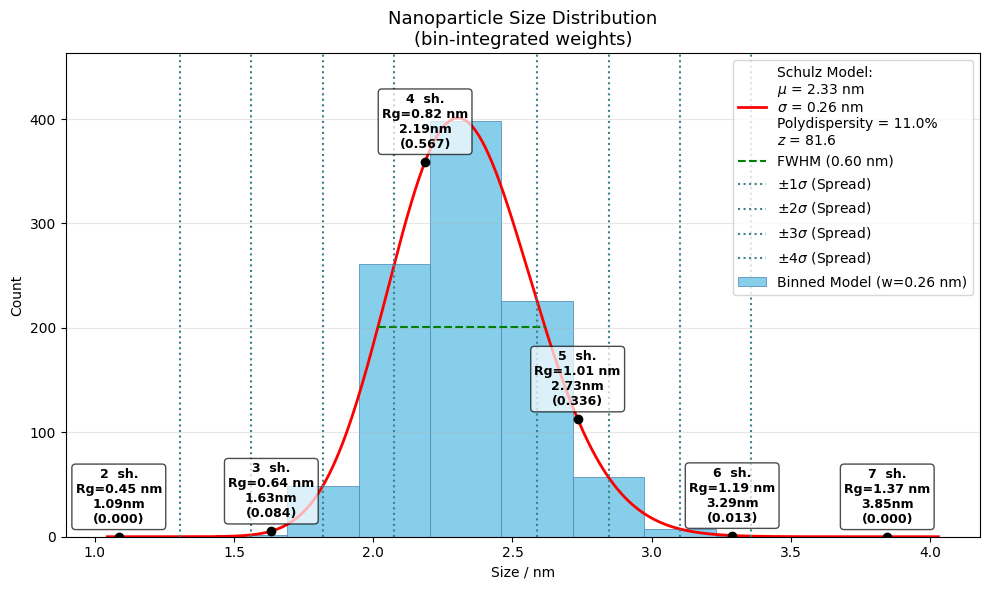

In [7]:
nd.plot(highlight_sizes=[D, labels])

<div class="rqE">

The figure above shows the Schulz size distribution with the magic-number icosahedra superimposed. Two perfect structures bracket the mean: the 4-shell icosahedron at 2.19 nm (weight 0.751) lies close to μ, while the 5-shell at 2.73 nm (weight 0.236) sits near μ+2σ. No perfect icosahedron falls on μ−σ or μ+σ.

To fill these gaps, we will use `peel_by_shifted_ellipsoid()`, which generates icosahedra with an incomplete outer shell by shifting the center of the truncating ellipsoid. This approach is more physically realistic than simple coordination-number peeling, as it produces smooth, faceted surface truncations similar to those expected from growth kinetics. Starting from the 4-shell structure, we will progressively remove part of the outer layer to reach ~2.08 nm (*μ*−*σ*); similarly, starting from the 5-shell, we will target ~2.59 nm (*μ*+*σ*). After geometry optimization, the actual dimensions will be measured and the exact SAXS weights computed.

</div>

#### Build intermediate structures, *i.e.* icosahedra with a partially filled outer shell [1]

<div class='rqE'>

First run Step 1, to instantiate `nd` then run the "Bracketing around the 4-shell icosahedron" part.
</div>

##### `peel_by_shifted_ellipsoid`

In [ ]:
DNew = D.copy()
labelsNew = labels.copy()

In [ ]:
pyNMBu.centerTitle("4 shells (1)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.peel_by_shifted_ellipsoid(shift_dist=3, noOutput=False)
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1.xyz", ico4p.NP)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p1_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p1\nRg={ico4p_Rg:.2f} nm")

In [ ]:
pyNMBu.centerTitle("4 shells (2)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.peel_by_shifted_ellipsoid(shift_dist=5, noOutput=False)
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2.xyz", ico4p.NP)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_04p2_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. p2\nRg={ico4p_Rg:.2f} nm")

In [ ]:
pyNMBu.centerTitle("5 shells")
import pyNanoMatBuilder as pyNMB
ico5p = pyNMB.from_file("coords/ico_05_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
pyNMBu.compare_effective_diameters(ico5p);
ico5p.peel_by_shifted_ellipsoid(shift_dist=3, noOutput=False)
ico5p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p.xyz", ico5p.NP)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p.script", ico5p.jMolCS)
ico5p.optimize()
ico5p_D = ico5p.effective_diameter()/10
ico5p_Rg = ico5p.Rg_opt
print(f"Average diameter = {ico5p_D:.2f} nm\nRg={ico5p_Rg:.2f} nm")
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p_opt.xyz", ico5p.NP_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p_opt.script", ico5p.jMolCS_opt)
pyNMBu.write("coords/disp_shifted_ellipsoid/ico_05p_CS_opt.xyz", ico5p.NPcs_opt)

DNew.append(ico5p_D)
labelsNew.append(f"5 sh. p\nRg={ico5p_Rg:.2f} nm")
c = pyNMBu.compare_effective_diameters(ico5p);

##### Evaluate the relevance of the intermediate structures

<div class="intro">

We now overlay all the computed structures on the size distribution to visualize their positions and relative weights. `get_proportions()` returns, for each structure, its weight in the distribution, *i.e.* how much it would contribute to a weighted sum of individual SAXS signals.

Structures with negligible weight (close to 0) can be safely ignored in the SAXS simulation. In the next step, we filter out structures below a significance threshold and renormalize the remaining weights.

**Two weighting modes are available via the `use_bins` parameter.**

- `use_bins=True` (default, recommended) = **bin-integrated weights**:

    the distribution is integrated over a bin centered on each structure, with
    bin edges placed at the midpoints between consecutive target sizes. This
    correctly handles the case where several structures fall close together in
    size (e.g. three 4-shell variants between 2.03 and 2.19 nm and only one
    5-shell at 2.56 nm): each structure's weight reflects the fraction of the
    distribution *in its size neighbourhood*, regardless of how many other
    structures happen to lie nearby. The returned `norms` are absolute Cumulative Distribution Function (CDF)
    fractions (they sum to the total fraction of the distribution covered by
    the targets).

- `use_bins=False` = **pointwise weights**:

    the distribution is evaluated at each target diameter and normalized
    relative to a fine discretization of the full distribution. This is simpler
    but over-represents size ranges that have more simulated structures:
    if three structures are clustered at ~2.1 nm, their individual weights are
    each evaluated at their exact diameter, so the 2.1 nm region receives three
    times more total weight than it should.

In practice, always use `use_bins=True` when averaging SAXS signals over a
set of discrete structures — it is the only mode that guarantees that the
weighted average correctly approximates the integral:

$$\langle I(q) \rangle = \sum_i w_i\, I(q, D_i)
\quad \text{with} \quad
w_i = \int_{b_i^-}^{b_i^+} p(D)\, \mathrm{d}D$$

where $[b_i^-, b_i^+]$ is the bin centered on $D_i$ and $p(D)$ is the
Schulz (or Gaussian) number-weighted size distribution.
</div>

In [ ]:
nd.plot(highlight_sizes=[DNew, labelsNew], use_bins=True)
data = nd.get_proportions(DNew, labelsNew, use_bins=True)

##### Filter only structures with significant weight

<div class="intro">

Weights are stored in `data_filtered['norms_relative'])`
</div>

In [ ]:
data_filtered = nd.filter_proportions(data, threshold=0.05)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']])

##### Same but with `use_bins=False`

In [ ]:
nd.plot(highlight_sizes=[DNew, labelsNew], use_bins=False)
data = nd.get_proportions(DNew, labelsNew, use_bins=False)
data_filtered = nd.filter_proportions(data, threshold=0.05)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']], use_bins=False)

#### Build intermediate structures, *i.e.* icosahedra with a partially filled outer shell [2]

<div class='rqE'>

First run Step 1, to instantiate `nd` then run the "Bracketing around the 4-shell icosahedron" part.

</div>

##### Show the equations of all planes

Regular icosahedron with 7 shell(s) and Rnn = 2.7


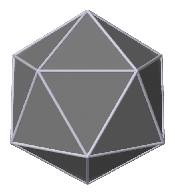

element =  Ag
number of vertices =  12
number of edges =  30
number of faces =  20
phi =  1.618033988749895
intershell factor = 1.05
nearest neighbour distance = 2.70 Å
intershell distance = 2.57 Å
edge length = 1.89 nm
radius after volume = 1.52 nm
radius of the circumscribed sphere = 1.80 nm
radius of the inscribed sphere = 1.43 nm
area = 30.9 nm2
volume = 14.7 nm3
number of atoms per shell =  [1, 12, 42, 92, 162, 252, 362, 492]
cumulative number of atoms per shell =  [1, 13, 55, 147, 309, 561, 923, 1415]
total number of atoms =  1415
Dual polyhedron: dodecahedron


Total number of atoms = 1415
[1, 12, 42, 92, 162, 252, 362, 492]
Duration : 00:00:00 013ms


Moments of inertia = 16360506.60 16360506.60 16360506.60 amu.Å2
Moments of inertia / M = 107.19 107.19 107.19 amu.Å2
Moments of inertia with mass=1/M = 107.19 107.19 107.19 Å2


 Principal Moments : I1=107.19, I2=107.19, I3=107.19
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 1.3 nm


Found:
  - 12 vertices
  - 20 simplices
  - Volume: 14.73 nm³
  - Area: 30.94 nm²
Duration : 00:00:00 001ms


492 atoms lie in the plane(s)
Duration : 00:00:00 001ms


Diameter of the circumscribed sphere: 35.95 Å
Diameter of the inscribed sphere: 28.57 Å


  - Dimensions (Å): 35.95 x 35.95 x 35.95
  - Volume: 24.33 nm³
  - Surface: 40.60 nm²
  - Asphericity: 1.00
  - Max Radius found: 1.797 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID initial_structure_el AXES {17.974968 0.000000 0.000000} {0.000000 -12.710222 12.710222} {0.000000 -12.710222 -12.710222}; ellipsoid ID initial_structure_el CENTER {0.000 0.000 0.000}; color $initial_structure_el [x919191] translucent 0.3;



─────────────────────────────────────────────────────────────
Plane (hkl)                 d / nm      e_rel      Area (nm²)
─────────────────────────────────────────────────────────────
  ( 1  1  1)                   1.43      1.000           1.55
  [-0.357 -0.000 -0.934]       1.43      1.000           1.55
  [-0.000 +0.934 -0.357]       1.43      1.000           1.55
  [-0.357 +0.000 +0.934]       1.43      1.000           1.55
  ( 1 -1  1)                   1.43      1.000           1.55
  [+0.934 +0.357 -0.000]       1.43      1.000           1.55
  [+0.357 +0.000 +0.934]       1.43      1.000           1.55
  [-0.000 -0.934 -0.357]       1.43      1.000           1.55
  [+0.934 -0.357 -0.000]       1.43      1.000           1.55
  (-1 -1  1)                   1.43      1.000           1.55
  [-0.934 -0.357 -0.000]       1.43      1.000           1.55
  [-0.000 -0.934 +0.357]       1.43      1.000           1.55
  (-1  1 -1)                   1.43      1.000           1.55
  (-1 -

In [65]:
ico = pNP.regIco("Ag",
                 2.7,
                 nshell,
                 skipSymmetryAnalyzis=True,
                 noOutput=False, skipFacetInfo=False,
                )

In [67]:
ico5 = pyNMB.from_file("coords/disp/ico_05.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=False, noOutput=False)
pyNMBu.write("coords/disp/ico_05.script",ico5.jMolCS)

Moments of inertia = 3483379.35 3483379.35 3483379.35 amu.Å2
Moments of inertia / M = 57.56 57.56 57.56 amu.Å2
Moments of inertia with mass=1/M = 57.56 57.56 57.56 Å2


 Principal Moments : I1=57.56, I2=57.56, I3=57.56
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.9 nm


Found:
  - 36 vertices
  - 68 simplices
  - Volume: 5.37 nm³
  - Area: 15.78 nm²
Duration : 00:00:00 003ms


252 atoms lie in the plane(s)
Duration : 00:00:00 004ms


Diameter of the circumscribed sphere: 25.68 Å
Diameter of the inscribed sphere: 20.41 Å


  - Dimensions (Å): 25.68 x 25.68 x 25.68
  - Volume: 8.87 nm³
  - Surface: 20.72 nm²
  - Asphericity: 1.00
  - Max Radius found: 1.284 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID initial_structure_el AXES {-0.000000 12.827582 0.547543} {12.839263 0.000000 0.000000} {0.000000 0.547543 -12.827582}; ellipsoid ID initial_structure_el CENTER {0.000 0.000 -0.000}; color $initial_structure_el [x919191] translucent 0.3;



─────────────────────────────────────────────────────────────
Plane (hkl)                 d / nm      e_rel      Area (nm²)
─────────────────────────────────────────────────────────────
  [-0.866 -0.178 +0.467]       0.39      2.119           1.14
  [-0.357 +0.389 +0.849]       0.18      1.000           0.91
  [+0.866 +0.178 -0.467]       0.39      2.119           0.83
  [+0.085 -0.420 -0.903]       0.70      3.824           0.81
  [+0.866 +0.178 +0.467]       0.39      2.119           0.50
  [+0.000 -0.526 +0.851]       0.57      3.122           0.46
  [+0.085 +0.420 -0.903]       0.70      3.824           0.45
  [+0.000 +0.934 +0.357]       1.02      5.548           0.35
  [-0.560 +0.816 -0.145]       0.71      3.857           0.31
  [-0.866 +0.178 +0.467]       0.39      2.119           0.29
  [-0.588 -0.688 -0.425]       0.93      5.052           0.14
  (-3  1 -9)                   0.97      5.252           0.06
  [-0.087 +0.621 +0.779]       0.43      2.343           0.01
  [-0.1

##### `remove_plane`

In [71]:
DNew = D.copy()
labelsNew = labels.copy()
print(DNew)

[np.float64(1.0863900936620705), np.float64(1.6341472326824522), np.float64(2.1862826757224982), np.float64(2.734131096042577), np.float64(3.2890053143670395), np.float64(3.845894039351124)]


In [72]:
pyNMBu.centerTitle("4 shells (1 plane)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04pl1.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04pl1.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04pl1_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04pl1_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04pl1_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. pl1\nRg={ico4p_Rg:.2f} nm")

Moments of inertia = 1497605.82 1497605.82 1497605.82 amu.Å2
Moments of inertia / M = 44.93 44.93 44.93 amu.Å2
Moments of inertia with mass=1/M = 44.93 44.93 44.93 Å2


 Principal Moments : I1=44.93, I2=44.93, I3=44.93
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.8 nm


Found:
  - 162 vertices
  - 320 simplices
  - Volume: 3.50 nm³
  - Area: 11.70 nm²
Duration : 00:00:00 003ms


162 atoms lie in the plane(s)
Duration : 00:00:00 011ms


...

 Rg = 0.8 nm


Found:
  - 147 vertices
  - 290 simplices
  - Volume: 3.34 nm³
  - Area: 11.39 nm²
Duration : 00:00:00 002ms


157 atoms lie in the plane(s)
Duration : 00:00:00 004ms


Diameter of the circumscribed sphere: 22.08 Å
Diameter of the inscribed sphere: 15.16 Å


  - Dimensions (Å): 22.30 x 22.30 x 19.45
  - Volume: 5.07 nm³
  - Surface: 14.31 nm²
  - Asphericity: 1.15
  - Max Radius found: 1.115 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {0.000000 -7.884874 7.884874} {-9.104668 -4.552334 -4.552334} {-5.615195 5.615195 5.615195}; ellipsoid ID optimized_structure_el CENTER {-0.263 0.263 0.263}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:00 277ms
Average diameter = 2.14 nm
Rg=0.81 nm


In [73]:
pyNMBu.centerTitle("4 shells (2 planes)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico4p.remove_plane(axis_def="cart", direction=[+0.00, -0.93, -0.36])
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04pl2.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04pl2.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04pl2_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04pl2_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04pl2_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. pl2\nRg={ico4p_Rg:.2f} nm")

Moments of inertia = 1497605.82 1497605.82 1497605.82 amu.Å2
Moments of inertia / M = 44.93 44.93 44.93 amu.Å2
Moments of inertia with mass=1/M = 44.93 44.93 44.93 Å2


 Principal Moments : I1=44.93, I2=44.93, I3=44.93
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.8 nm


Found:
  - 162 vertices
  - 320 simplices
  - Volume: 3.50 nm³
  - Area: 11.70 nm²
Duration : 00:00:00 002ms


162 atoms lie in the plane(s)
Duration : 00:00:00 004ms


...

 Rg = 0.8 nm


Found:
  - 141 vertices
  - 278 simplices
  - Volume: 3.21 nm³
  - Area: 11.12 nm²
Duration : 00:00:00 002ms


153 atoms lie in the plane(s)
Duration : 00:00:00 004ms


Diameter of the circumscribed sphere: 21.95 Å
Diameter of the inscribed sphere: 15.42 Å


  - Dimensions (Å): 22.04 x 21.11 x 18.24
  - Volume: 4.44 nm³
  - Surface: 13.14 nm²
  - Asphericity: 1.21
  - Max Radius found: 1.102 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {5.509776 -3.405229 8.915005} {8.537248 5.276310 -3.260939} {-2.818205 7.378158 4.559952}; ellipsoid ID optimized_structure_el CENTER {-0.165 0.431 0.266}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:00 417ms
Average diameter = 2.05 nm
Rg=0.80 nm


In [74]:
pyNMBu.centerTitle("4 shells (3 planes)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico4p.remove_plane(axis_def="cart", direction=[0.00, -0.93, -0.36])
ico4p.remove_plane(axis_def="cart", direction=[0.36,  0.00, -0.93])
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04pl3.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04pl3.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04pl3_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04pl3_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04pl3_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. pl3\nRg={ico4p_Rg:.2f} nm")

Moments of inertia = 1497605.82 1497605.82 1497605.82 amu.Å2
Moments of inertia / M = 44.93 44.93 44.93 amu.Å2
Moments of inertia with mass=1/M = 44.93 44.93 44.93 Å2


 Principal Moments : I1=44.93, I2=44.93, I3=44.93
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.8 nm


Found:
  - 162 vertices
  - 320 simplices
  - Volume: 3.50 nm³
  - Area: 11.70 nm²
Duration : 00:00:00 002ms


162 atoms lie in the plane(s)
Duration : 00:00:00 004ms


...

 Rg = 0.8 nm


Found:
  - 134 vertices
  - 264 simplices
  - Volume: 3.09 nm³
  - Area: 10.85 nm²
Duration : 00:00:00 002ms


149 atoms lie in the plane(s)
Duration : 00:00:00 004ms


Diameter of the circumscribed sphere: 22.16 Å
Diameter of the inscribed sphere: 15.38 Å


  - Dimensions (Å): 22.54 x 21.07 x 18.90
  - Volume: 4.70 nm³
  - Surface: 13.63 nm²
  - Asphericity: 1.19
  - Max Radius found: 1.127 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {10.008744 -0.644267 5.143298} {-3.255356 -8.522634 5.267277} {3.219324 -5.529575 -6.957388}; ellipsoid ID optimized_structure_el CENTER {-0.163 0.372 0.500}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:00 405ms
Average diameter = 2.09 nm
Rg=0.79 nm


In [75]:
pyNMBu.centerTitle("4 shells (5 planes)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.remove_plane(axis_def="cart", direction=[+0.5774, -0.5774, -0.5774])  # 0°   (1-1-1)
ico4p.remove_plane(axis_def="cart", direction=[+0.3568, -0.0000, -0.9342])  # 72°
ico4p.remove_plane(axis_def="cart", direction=[+0.5773, +0.5773, -0.5774])  # 144° ≈ (1 1-1)
ico4p.remove_plane(axis_def="cart", direction=[+0.9342, +0.3568, -0.0000])  # 216°
ico4p.remove_plane(axis_def="cart", direction=[+0.9342, -0.3568, -0.0000])  # 288°
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_04pl5.xyz", ico4p.NP)
pyNMBu.write("coords/disp_plane/ico_04pl5.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()/10
ico4p_Rg = ico4p.Rg_opt
print(f"Average diameter = {ico4p_D:.2f} nm\nRg={ico4p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_04pl5_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_04pl5_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_04pl5_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append(f"4 sh. pl5\nRg={ico4p_Rg:.2f} nm")
pyNMBu.compare_effective_diameters(ico4p)

Moments of inertia = 1282410.58 1282410.58 1282410.58 amu.Å2
Moments of inertia / M = 38.47 38.47 38.47 amu.Å2
Moments of inertia with mass=1/M = 38.47 38.47 38.47 Å2


 Principal Moments : I1=38.47, I2=38.47, I3=38.47
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.8 nm


Found:
  - 12 vertices
  - 20 simplices
  - Volume: 2.75 nm³
  - Area: 10.10 nm²
Duration : 00:00:00 001ms


162 atoms lie in the plane(s)
Duration : 00:00:00 001ms


...

142 atoms lie in the plane(s)
Duration : 00:00:00 003ms


Diameter of the circumscribed sphere: 20.78 Å
Diameter of the inscribed sphere: 15.83 Å


  - Dimensions (Å): 20.86 x 20.86 x 20.60
  - Volume: 4.69 nm³
  - Surface: 13.56 nm²
  - Asphericity: 1.01
  - Max Radius found: 1.043 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {0.000000 -10.429774 0.000000} {-5.483257 -0.000000 -8.872096} {-8.763014 0.000000 5.415841}; ellipsoid ID optimized_structure_el CENTER {-0.589 -0.000 0.364}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:01 534ms
Average diameter = 2.08 nm
Rg=0.78 nm


initial  optimized
method     mode                        
feret      —          1.7577     1.8738
rg         —          1.8576     2.0037
rms        vertices   2.1760     2.0774
           all        2.1760     2.0325
           planes     2.1760     1.7904
volume     vertices   2.1732     2.0774
           all        2.1732     2.0303
           planes     2.1732     1.7863
arithmetic vertices   2.1746     2.0774
           all        2.1746     2.0314
           planes     2.1746     1.7883
surface    vertices   2.1743     2.0774
           all        2.1743     2.0312
           planes     2.1743     1.7880

initial  optimized
method     mode                        
feret      —          1.7577     1.8738
rg         —          1.8576     2.0037
rms        vertices   2.1760     2.0774
           all        2.1760     2.0325
           planes     2.1760     1.7904
volume     vertices   2.1732     2.0774
           all        2.1732     2.0303
           planes     2.1732     1.7863
arithmetic vertices   2.1746     2.0774
           all        2.1746     2.0314
           planes     2.1746     1.7883
surface    vertices   2.1743     2.0774
           all        2.1743     2.0312
           planes     2.1743     1.7880

In [76]:
pyNMBu.centerTitle("5 shells (2 planes)")
import pyNanoMatBuilder as pyNMB
ico5p = pyNMB.from_file("coords/ico_05_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico5p.remove_plane(axis_def="cart", direction=[1, -1, -1])
ico5p.remove_plane(axis_def="cart", direction=[+0.00, -0.93, -0.36])
ico5p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_05pl2.xyz", ico5p.NP)
pyNMBu.write("coords/disp_plane/ico_05pl2.script", ico5p.jMolCS)
ico5p.optimize()
ico5p_D = ico5p.effective_diameter()/10
ico5p_Rg = ico5p.Rg_opt
print(f"Average diameter = {ico5p_D:.2f} nm\nRg={ico5p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_05pl2_opt.xyz", ico5p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_05pl2_opt.script", ico5p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_05pl2_CS_opt.xyz", ico5p.NPcs_opt)

DNew.append(ico5p_D)
labelsNew.append(f"5 sh. pl2\nRg={ico5p_Rg:.2f} nm")

Moments of inertia = 4080085.11 4080085.11 4080085.11 amu.Å2
Moments of inertia / M = 67.42 67.42 67.42 amu.Å2
Moments of inertia with mass=1/M = 67.42 67.42 67.42 Å2


 Principal Moments : I1=67.42, I2=67.42, I3=67.42
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 1.0 nm


Found:
  - 252 vertices
  - 500 simplices
  - Volume: 6.87 nm³
  - Area: 18.32 nm²
Duration : 00:00:00 002ms


252 atoms lie in the plane(s)
Duration : 00:00:00 006ms


...

 Rg = 1.0 nm


Found:
  - 221 vertices
  - 438 simplices
  - Volume: 6.44 nm³
  - Area: 17.64 nm²
Duration : 00:00:00 002ms


241 atoms lie in the plane(s)
Duration : 00:00:00 006ms


Diameter of the circumscribed sphere: 27.45 Å
Diameter of the inscribed sphere: 19.90 Å


  - Dimensions (Å): 27.57 x 26.58 x 23.19
  - Volume: 8.90 nm³
  - Surface: 20.86 nm²
  - Asphericity: 1.19
  - Max Radius found: 1.378 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {6.891982 -4.259479 11.151461} {10.751768 6.644958 -4.106810} {-3.582839 9.379994 5.797155}; ellipsoid ID optimized_structure_el CENTER {-0.231 0.604 0.373}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:01 817ms
Average diameter = 2.58 nm
Rg=0.99 nm


In [77]:
pyNMBu.centerTitle("5 shells (5 planes)")
import pyNanoMatBuilder as pyNMB
ico5p = pyNMB.from_file("coords/ico_05.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico5p.remove_plane(axis_def="cart", direction=[+0.5774, -0.5774, -0.5774])  # 0°   (1-1-1)
ico5p.remove_plane(axis_def="cart", direction=[+0.3568, -0.0000, -0.9342])  # 72°
ico5p.remove_plane(axis_def="cart", direction=[+0.5773, +0.5773, -0.5774])  # 144° ≈ (1 1-1)
ico5p.remove_plane(axis_def="cart", direction=[+0.9342, +0.3568, -0.0000])  # 216°
ico5p.remove_plane(axis_def="cart", direction=[+0.9342, -0.3568, -0.0000])  # 288°
ico4p.remove_plane(axis_def="cart", direction=[0.00, -0.93, -0.36])
ico4p.remove_plane(axis_def="cart", direction=[0.36,  0.00, -0.93])
ico5p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_05pl5.xyz", ico5p.NP)
pyNMBu.write("coords/disp_plane/ico_05pl5.script", ico5p.jMolCS)
ico5p.optimize()
ico5p_D = ico5p.effective_diameter()/10
ico5p_Rg = ico5p.Rg_opt
print(f"Average diameter = {ico5p_D:.2f} nm\nRg={ico5p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_05pl5_opt.xyz", ico5p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_05pl5_opt.script", ico5p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_05pl5_CS_opt.xyz", ico5p.NPcs_opt)

DNew.append(ico5p_D)
labelsNew.append(f"5 sh. pl5\nRg={ico5p_Rg:.2f} nm")
pyNMBu.compare_effective_diameters(ico5p)

Moments of inertia = 3483379.35 3483379.35 3483379.35 amu.Å2
Moments of inertia / M = 57.56 57.56 57.56 amu.Å2
Moments of inertia with mass=1/M = 57.56 57.56 57.56 Å2


 Principal Moments : I1=57.56, I2=57.56, I3=57.56
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.9 nm


Found:
  - 36 vertices
  - 68 simplices
  - Volume: 5.37 nm³
  - Area: 15.78 nm²
Duration : 00:00:00 002ms


252 atoms lie in the plane(s)
Duration : 00:00:00 002ms


...

227 atoms lie in the plane(s)
Duration : 00:00:00 005ms


Diameter of the circumscribed sphere: 26.32 Å
Diameter of the inscribed sphere: 20.29 Å


  - Dimensions (Å): 26.93 x 26.93 x 26.93
  - Volume: 10.23 nm³
  - Surface: 22.79 nm²
  - Asphericity: 1.00
  - Max Radius found: 1.347 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {-0.000063 -13.466095 -0.000102} {7.079545 -0.000120 11.454945} {11.454945 0.000000 -7.079545}; ellipsoid ID optimized_structure_el CENTER {-0.917 -0.000 0.567}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:02 261ms
Average diameter = 2.69 nm
Rg=0.96 nm


initial  optimized
method     mode                        
feret      —          2.2270     2.3830
rg         —          2.2946     2.4817
rms        vertices   2.3923     2.6932
           all        2.3923     2.5872
           planes     2.3923     2.3005
volume     vertices   2.3902     2.6932
           all        2.3902     2.5856
           planes     2.3902     2.2990
arithmetic vertices   2.3912     2.6932
           all        2.3912     2.5864
           planes     2.3912     2.2997
surface    vertices   2.3910     2.6932
           all        2.3910     2.5862
           planes     2.3910     2.2996

initial  optimized
method     mode                        
feret      —          2.2270     2.3830
rg         —          2.2946     2.4817
rms        vertices   2.3923     2.6932
           all        2.3923     2.5872
           planes     2.3923     2.3005
volume     vertices   2.3902     2.6932
           all        2.3902     2.5856
           planes     2.3902     2.2990
arithmetic vertices   2.3912     2.6932
           all        2.3912     2.5864
           planes     2.3912     2.2997
surface    vertices   2.3910     2.6932
           all        2.3910     2.5862
           planes     2.3910     2.2996

In [82]:
pyNMBu.centerTitle("5 shells (15 planes)")
import pyNanoMatBuilder as pyNMB
ico15p = pyNMB.from_file("coords/ico_05.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico15p.remove_plane(axis_def="cart", direction=[1,1,1])
ico15p.remove_plane(axis_def="cart", direction=[-0.357, -0.000, -0.934])
ico15p.remove_plane(axis_def="cart", direction=[0.000, +0.934, -0.357])
ico15p.remove_plane(axis_def="cart", direction=[-0.357, +0.000, +0.934])
ico15p.remove_plane(axis_def="cart", direction=[ 1, -1,  1])
ico15p.remove_plane(axis_def="cart", direction=[+0.357, +0.000, +0.934])
ico15p.remove_plane(axis_def="cart", direction=[-0.000, -0.934, -0.357])
ico15p.remove_plane(axis_def="cart", direction=[-1, -1,  1])
ico15p.remove_plane(axis_def="cart", direction=[-0.934, -0.357, -0.000])
ico15p.remove_plane(axis_def="cart", direction=[-0.000, -0.934, +0.357])
ico15p.remove_plane(axis_def="cart", direction=[-1,  1, -1])
ico15p.remove_plane(axis_def="cart", direction=[-1, -1, -1])
ico15p.remove_plane(axis_def="cart", direction=[+0.000, +0.934, +0.357])
ico15p.remove_plane(axis_def="cart", direction=[-0.934, +0.357, +0.000])
ico15p.remove_plane(axis_def="cart", direction=[-1,  1,  1])
ico15p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/disp_plane/ico_05pl15.xyz", ico15p.NP)
pyNMBu.write("coords/disp_plane/ico_05pl15.script", ico15p.jMolCS)
ico15p.optimize()
ico15p_D = ico15p.effective_diameter()/10
ico15p_Rg = ico15p.Rg_opt
print(f"Average diameter = {ico15p_D:.2f} nm\nRg={ico15p_Rg:.2f} nm")
pyNMBu.write("coords/disp_plane/ico_05pl15_opt.xyz", ico15p.NP_opt)
pyNMBu.write("coords/disp_plane/ico_05pl15_opt.script", ico15p.jMolCS_opt)
pyNMBu.write("coords/disp_plane/ico_05pl15_CS_opt.xyz", ico15p.NPcs_opt)

DNew.append(ico15p_D)
labelsNew.append(f"5 sh. pl15\nRg={ico15p_Rg:.2f} nm")
pyNMBu.compare_effective_diameters(ico15p)

Moments of inertia = 3483379.35 3483379.35 3483379.35 amu.Å2
Moments of inertia / M = 57.56 57.56 57.56 amu.Å2
Moments of inertia with mass=1/M = 57.56 57.56 57.56 Å2


 Principal Moments : I1=57.56, I2=57.56, I3=57.56
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 0.9 nm


Found:
  - 36 vertices
  - 68 simplices
  - Volume: 5.37 nm³
  - Area: 15.78 nm²
Duration : 00:00:00 001ms


252 atoms lie in the plane(s)
Duration : 00:00:00 002ms


...

182 atoms lie in the plane(s)
Duration : 00:00:00 004ms


Diameter of the circumscribed sphere: 24.62 Å
Diameter of the inscribed sphere: 17.72 Å


  - Dimensions (Å): 25.42 x 21.02 x 21.02
  - Volume: 5.88 nm³
  - Surface: 15.86 nm²
  - Asphericity: 1.21
  - Max Radius found: 1.271 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {-10.812940 0.000000 6.682765} {5.525847 0.000210 8.941008} {0.000110 -10.510785 0.000178}; ellipsoid ID optimized_structure_el CENTER {-0.341 0.000 0.211}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:01 193ms
Average diameter = 2.26 nm
Rg=0.87 nm


initial  optimized
method     mode                        
feret      —          2.0054     2.1428
rg         —          2.0785     2.2459
rms        vertices   2.7306     2.2584
           all        2.7306     2.2585
           planes     2.7306     2.0051
volume     vertices   2.7213     2.2397
           all        2.7213     2.2490
           planes     2.7213     1.9975
arithmetic vertices   2.7259     2.2489
           all        2.7259     2.2537
           planes     2.7259     2.0012
surface    vertices   2.7250     2.2466
           all        2.7250     2.2526
           planes     2.7250     2.0004

initial  optimized
method     mode                        
feret      —          2.0054     2.1428
rg         —          2.0785     2.2459
rms        vertices   2.7306     2.2584
           all        2.7306     2.2585
           planes     2.7306     2.0051
volume     vertices   2.7213     2.2397
           all        2.7213     2.2490
           planes     2.7213     1.9975
arithmetic vertices   2.7259     2.2489
           all        2.7259     2.2537
           planes     2.7259     2.0012
surface    vertices   2.7250     2.2466
           all        2.7250     2.2526
           planes     2.7250     2.0004

##### Evaluate the relevance of the intermediate structures

<div class="intro">

We now overlay all the computed structures on the size distribution to visualize their positions and relative weights. `get_proportions()` returns, for each structure, its weight in the distribution, *i.e.* how much it would contribute to a weighted sum of individual SAXS signals.

Structures with negligible weight (close to 0) can be safely ignored in the SAXS simulation. In the next step, we filter out structures below a significance threshold and renormalize the remaining weights.

**Two weighting modes are available via the `use_bins` parameter.**

- `use_bins=True` (default, recommended) = **bin-integrated weights**:

    the distribution is integrated over a bin centered on each structure, with
    bin edges placed at the midpoints between consecutive target sizes. This
    correctly handles the case where several structures fall close together in
    size (e.g. three 4-shell variants between 2.03 and 2.19 nm and only one
    5-shell at 2.56 nm): each structure's weight reflects the fraction of the
    distribution *in its size neighbourhood*, regardless of how many other
    structures happen to lie nearby. The returned `norms` are absolute Cumulative Distribution Function (CDF)
    fractions (they sum to the total fraction of the distribution covered by
    the targets).

- `use_bins=False` = **pointwise weights**:

    the distribution is evaluated at each target diameter and normalized
    relative to a fine discretization of the full distribution. This is simpler
    but over-represents size ranges that have more simulated structures:
    if three structures are clustered at ~2.1 nm, their individual weights are
    each evaluated at their exact diameter, so the 2.1 nm region receives three
    times more total weight than it should.

In practice, always use `use_bins=True` when averaging SAXS signals over a
set of discrete structures — it is the only mode that guarantees that the
weighted average correctly approximates the integral:

$$\langle I(q) \rangle = \sum_i w_i\, I(q, D_i)
\quad \text{with} \quad
w_i = \int_{b_i^-}^{b_i^+} p(D)\, \mathrm{d}D$$

where $[b_i^-, b_i^+]$ is the bin centered on $D_i$ and $p(D)$ is the
Schulz (or Gaussian) number-weighted size distribution.
</div>

  2  sh. Rg=0.45 nm                   D=1.0864 nm → bin [0.9211, 1.1777]  (1 structure in bin, intra-bin share=1.000)
  3  sh. Rg=0.64 nm                   D=1.6341 nm → bin [1.6907, 1.9472]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [1.4342, 1.6907] → [1.6907, 1.9472] (rel_pos=0.78 > 0.75, right neighbor was empty)
  4  sh. Rg=0.82 nm                   D=2.1863 nm → bin [1.9472, 2.2037]  (5 structures in bin, intra-bin share=0.247)
  5  sh. Rg=1.01 nm                   D=2.7341 nm → bin [2.7168, 2.9733]  (1 structure in bin, intra-bin share=1.000)
  6  sh. Rg=1.19 nm                   D=3.2890 nm → bin [2.9733, 3.2298]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [3.2298, 3.4863] → [2.9733, 3.2298] (rel_pos=0.23 < 0.25, left neighbor was empty)
  7  sh. Rg=1.37 nm                   D=3.8459 nm → bin [3.7429, 3.9994]  (1 structure in bin, intra-bin share=1.000)
  4 sh. pl1 Rg=0.81 nm                D=2.1394 nm → bin [1.9472, 2.2037]  (5 struc

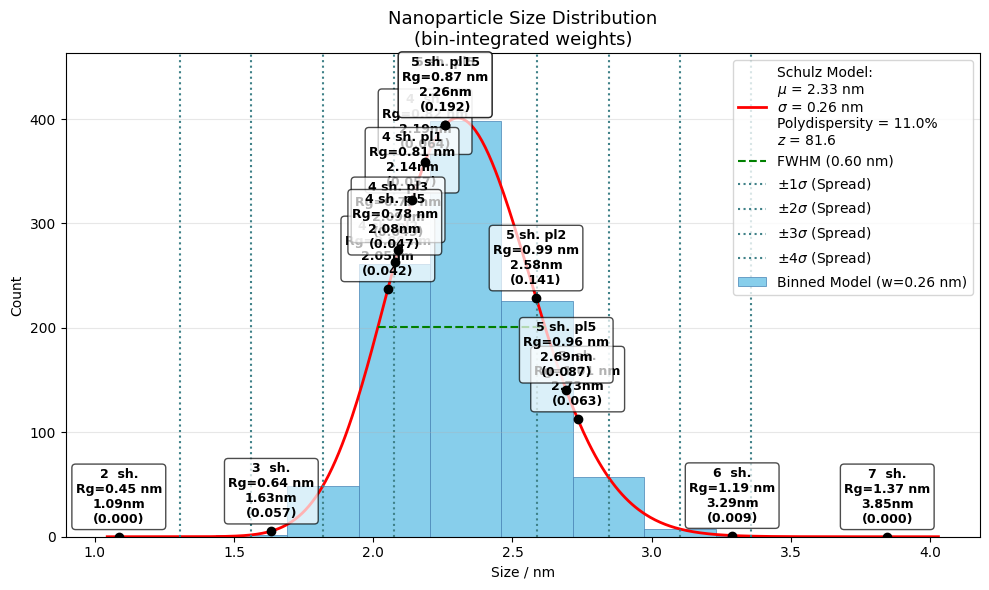

  2  sh. Rg=0.45 nm                   D=1.0864 nm → bin [0.9211, 1.1777]  (1 structure in bin, intra-bin share=1.000)
  3  sh. Rg=0.64 nm                   D=1.6341 nm → bin [1.6907, 1.9472]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [1.4342, 1.6907] → [1.6907, 1.9472] (rel_pos=0.78 > 0.75, right neighbor was empty)
  4  sh. Rg=0.82 nm                   D=2.1863 nm → bin [1.9472, 2.2037]  (5 structures in bin, intra-bin share=0.247)
  5  sh. Rg=1.01 nm                   D=2.7341 nm → bin [2.7168, 2.9733]  (1 structure in bin, intra-bin share=1.000)
  6  sh. Rg=1.19 nm                   D=3.2890 nm → bin [2.9733, 3.2298]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [3.2298, 3.4863] → [2.9733, 3.2298] (rel_pos=0.23 < 0.25, left neighbor was empty)
  7  sh. Rg=1.37 nm                   D=3.8459 nm → bin [3.7429, 3.9994]  (1 structure in bin, intra-bin share=1.000)
  4 sh. pl1 Rg=0.81 nm                D=2.1394 nm → bin [1.9472, 2.2037]  (5 struc

In [84]:
nd.plot(highlight_sizes=[DNew, labelsNew],use_bins=True)
data = nd.get_proportions(DNew, labelsNew,use_bins=True)

##### Filter only structures with significant weight

<div class="intro">

Weights are stored in `data_filtered['norms_relative'])`
</div>

['3  sh.\nRg=0.64 nm', '4 sh. pl2\nRg=0.80 nm', '4 sh. pl5\nRg=0.78 nm', '4 sh. pl3\nRg=0.79 nm', '4 sh. pl1\nRg=0.81 nm', '4  sh.\nRg=0.82 nm', '5 sh. pl15\nRg=0.87 nm', '5 sh. pl5\nRg=0.87 nm', '5 sh. pl2\nRg=0.99 nm', '5 sh. pl5\nRg=0.96 nm', '5  sh.\nRg=1.01 nm']
[0.05770025 0.04262206 0.0472072  0.04934088 0.05786807 0.06449042
 0.19392267 0.19392267 0.14238616 0.08740231 0.06313732]


  3  sh. Rg=0.64 nm                   D=1.6341 nm → bin [1.6907, 1.9472]  (1 structure in bin, intra-bin share=1.000)
      *** reassigned [1.4342, 1.6907] → [1.6907, 1.9472] (rel_pos=0.78 > 0.75, right neighbor was empty)
  4 sh. pl2 Rg=0.80 nm                D=2.0525 nm → bin [1.9472, 2.2037]  (5 structures in bin, intra-bin share=0.163)
  4 sh. pl5 Rg=0.78 nm                D=2.0774 nm → bin [1.9472, 2.2037]  (5 structures in bin, intra-bin share=0.181)
  4 sh. pl3 Rg=0.79 nm                D=2.0892 nm → bin [1.9472, 2.2037]  (5 structures in bin, intra-bin share=0.189)
  4 sh. pl1 Rg=0.81 nm                D=2.1394 nm → bin [1.9472, 2.2037]  (5 structures in bin, intra-bin share=0.221)
  4  sh. Rg=0.82 nm                   D=2.1863 nm → bin [1.9472, 2.2037]  (5 structures in bin, intra-bin share=0.247)
  5 sh. pl15 Rg=0.87 nm               D=2.2584 nm → bin [2.2037, 2.4603]  (2 structures in bin, intra-bin share=0.500)
  5 sh. pl5 Rg=0.87 nm                D=2.2584 nm → bin [2.2037

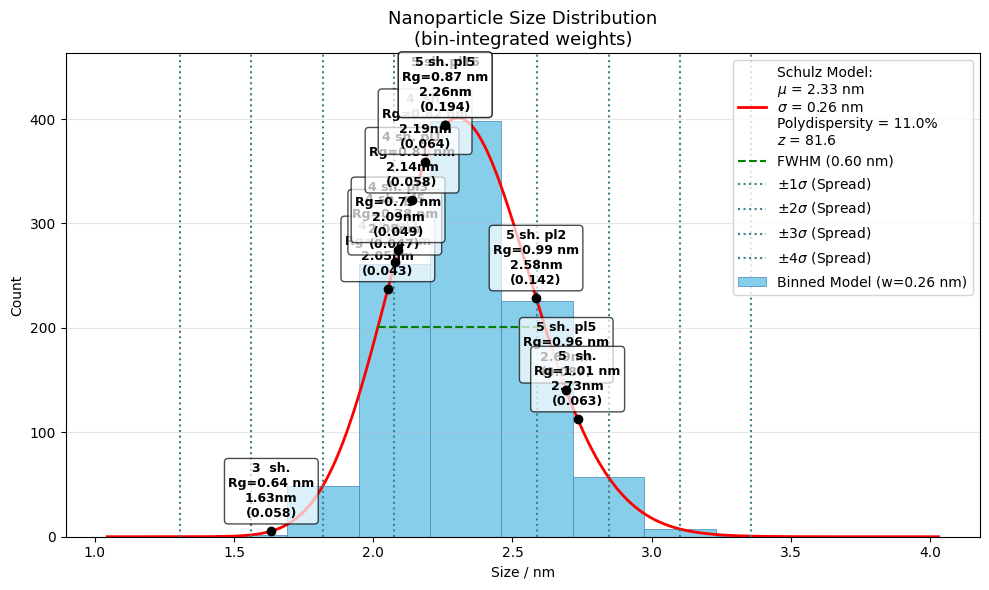

In [85]:
data_filtered = nd.filter_proportions(data, threshold=0.01)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']])

##### Same but with `use_bins=False`

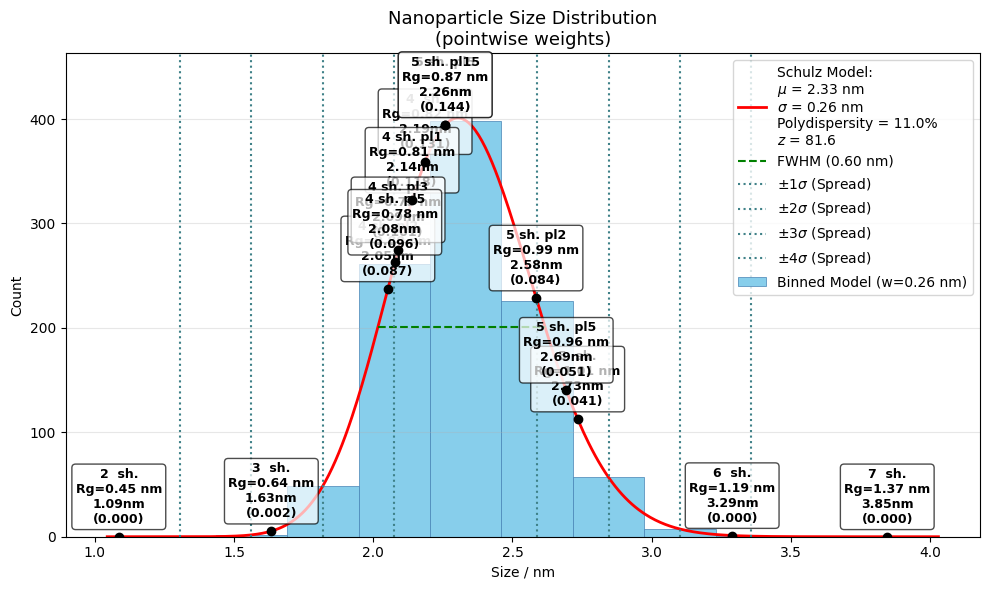

['4 sh. pl2\nRg=0.80 nm', '4 sh. pl5\nRg=0.78 nm', '4 sh. pl3\nRg=0.79 nm', '4 sh. pl1\nRg=0.81 nm', '4  sh.\nRg=0.82 nm', '5 sh. pl5\nRg=0.87 nm', '5 sh. pl15\nRg=0.87 nm', '5 sh. pl2\nRg=0.99 nm', '5 sh. pl5\nRg=0.96 nm']
[0.09079085 0.10055781 0.10510286 0.12326694 0.13737346 0.15089835
 0.15089835 0.08743827 0.0536731 ]


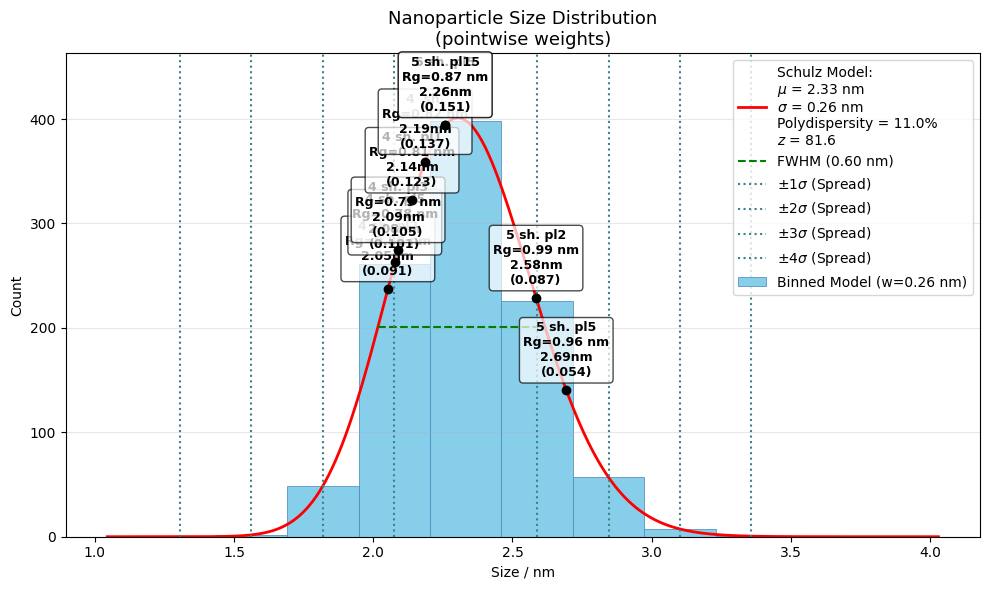

In [86]:
data_filtered_bins = data_filtered.copy()
nd.plot(highlight_sizes=[DNew, labelsNew], use_bins=False)
data = nd.get_proportions(DNew, labelsNew, use_bins=False)
# data = nd.get_proportions_old(DNew, labelsNew)
# print(data_filtered['norms_relative'])
data_filtered = nd.filter_proportions(data, threshold=0.05)
print(data_filtered['labels'])
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']], use_bins=False)

In [31]:
nd.compare_proportions(data_filtered_bins, data_filtered);

,Label,D (nm),Bin [nm],n in bin,Bin CDF w,w (bins),w (pointwise),Δw,Σ w(bins) in bin,Check (Σ-CDF)
0,3 sh. Rg=0.64 nm,1.6341,"[1.6907, 1.9472]",1,0.0577,0.0577,—,—,0.0577,+0.0000
1,4 sh. pl2 Rg=0.80 nm,2.0525,"[1.9472, 2.2037]",4,0.2615,0.0566,0.1320,-0.0755,0.2615,+0.0000
2,4 sh. pl5 Rg=0.78 nm,2.0774,"[1.9472, 2.2037]",4,0.2615,0.0627,0.1462,-0.0836,0.2615,+0.0000
3,4 sh. pl3 Rg=0.79 nm,2.0892,"[1.9472, 2.2037]",4,0.2615,0.0655,0.1528,-0.0874,0.2615,+0.0000
4,4 sh. pl1 Rg=0.81 nm,2.1394,"[1.9472, 2.2037]",4,0.2615,0.0768,0.1793,-0.1025,0.2615,+0.0000
5,4 sh. Rg=0.82 nm,2.1863,"[2.2037, 2.4603]",1,0.3878,0.3878,0.1998,+0.1881,0.3878,+0.0000
6,5 sh. pl2 Rg=0.99 nm,2.5847,"[2.4603, 2.7168]",1,0.2298,0.2298,0.1272,+0.1026,0.2298,+0.0000
7,5 sh. Rg=1.01 nm,2.7341,"[2.7168, 2.9733]",1,0.0631,0.0631,0.0627,+0.0004,0.0631,+0.0000


## Morphing

### fcc cube to octahedron

<div class="intro">

see for example [ 10.1039/d0nr03637d](https://doi.org/10.1039/d0nr03637d)

**The workflow is the following**:

1. Build the reference cube via Wulff construction (`surfacesWulff=[[1,0,0]]`)
   and compute its diagonal and edge length from `effective_diameter()`.
2. Progressively truncate the cube by introducing {111} planes at decreasing
   distances (step = one {111} interplanar spacing `d111`), generating a series
   of intermediate Wulff structures from cube to truncated octahedron.
3. Render each frame as a PNG using `pyNMBu.render_frames_jmol()`.
4. Assemble the frames into a looping MP4 animation using `pyNMBu.frames_to_movie()`.

</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
import numpy as np

FeNP = cyNP.Crystal("Fe bcc",
                    shape='Wulff',
                    surfacesWulff=[[1,0,0]],
                    sizesWulff=[8],
                    skipSymmetryAnalyzis=True,
                    noOutput=True,
                    symWulff=True)
pyNMBu.write("animations/Febcc_cube.xyz", FeNP.NP)

d110 = FeNP.interPlanarSpacing([1, 1, 0], noOutput=False)
print(f"d110 interplanar spacing = {d110:.3f} Å")
diag = FeNP.effective_diameter()
print(f"Cube diagonal length = {diag/10:.3f} nm")
a = diag / 10 / np.sqrt(3)
print(f"Cube edge length = {a:.3f} nm")
d_edges = a * np.sqrt(2)
print(f"Distance between opposite edges = {d_edges:.3f} nm")
cut110_min = d_edges / 2
i_max = round((d_edges - cut110_min) / (2 * d110/10))
print((d_edges - cut110_min) / (2 * d110/10), i_max)

In [ ]:
for i in range(0, i_max+1):
    cut110 = d_edges - 2*i*d110/10
    print(f"{i:02d}. cut110 = {cut110:.2f} nm")
    FeNP = cyNP.Crystal("Fe bcc",
                        shape='Wulff',
                        surfacesWulff=[[1,0,0],[1,1,0]],
                        sizesWulff=[8,cut110],
                        skipSymmetryAnalyzis=True,
                        postAnalyzis=False,
                        noOutput=True,
                        skipFacetInfo=True,
                        symWulff=True)
    FeNP.external_facets_info(noOutput=False)
    pyNMBu.write(f"animations/Febcc_c_rdd_{i:02d}.xyz", FeNP.NP)



In [ ]:
# Render frames -> PNG, then assemble into a ping-pong MP4
view_script = "moveto 1.0 { 552 -833 -42 24.66} 100.0 0.0 0.0 {0.0 0.0 0.0} 67.60922 {0 0 0} 0 0 0 3.0 0.0 0.0; cpk; "
pngs = pyNMBu.render_frames_jmol(prefix="Febcc_c_rdd_",
                          n_frames=i_max+1,
                          view_script=view_script,
                          output_dir="animations",
                          boundaries=False,
                          cpk=1.7)
pyNMBu.frames_to_movie(pngs, "animations/Febcc_c_rdd_animation.mp4", fps=5, pingpong=True)

### bcc cube to rhombic dodecahedron

<div class="intro">

**The workflow is the following**:
1. Build the reference cube via Wulff construction (`surfacesWulff=[[1,0,0]]`)
   and compute its diagonal, edge length, and opposite-edge distance from
   `effective_diameter()`.
2. Progressively truncate the cube by introducing {110} planes at decreasing
   distances (step = one {110} interplanar spacing `d110`), generating a series
   of intermediate Wulff structures from cube to rhombic dodecahedron.
3. Render each frame as a PNG using `pyNMBu.render_frames_jmol()`.
4. Assemble the frames into a looping MP4 animation using `pyNMBu.frames_to_movie()`.
</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
import numpy as np

FeNP = cyNP.Crystal("Fe bcc",
                    shape='Wulff',
                    surfacesWulff=[[1,0,0]],
                    sizesWulff=[8],
                    skipSymmetryAnalyzis=True,
                    noOutput=True,
                    symWulff=True)
pyNMBu.write("animations/Febcc_cube.xyz", FeNP.NP)

d110 = FeNP.interPlanarSpacing([1, 1, 0], noOutput=False)
print(f"d110 interplanar spacing = {d110:.3f} Å")
diag = FeNP.effective_diameter()
print(f"Cube diagonal length = {diag/10:.3f} nm")
a = diag / 10 / np.sqrt(3)
print(f"Cube edge length = {a:.3f} nm")
d_edges = a * np.sqrt(2)
print(f"Distance between opposite edges = {d_edges:.3f} nm")
cut110_min = d_edges / 2
i_max = round((d_edges - cut110_min) / (2 * d110/10))
print((d_edges - cut110_min) / (2 * d110/10), i_max)

In [ ]:
for i in range(0, i_max+1):
    cut110 = d_edges - 2*i*d110/10
    print(f"{i:02d}. cut110 = {cut110:.2f} nm")
    FeNP = cyNP.Crystal("Fe bcc",
                        shape='Wulff',
                        surfacesWulff=[[1,0,0],[1,1,0]],
                        sizesWulff=[8,cut110],
                        skipSymmetryAnalyzis=True,
                        postAnalyzis=False,
                        noOutput=True,
                        skipFacetInfo=True,
                        symWulff=True)
    FeNP.external_facets_info(noOutput=False)
    pyNMBu.write(f"animations/Febcc_c_rdd_{i:02d}.xyz", FeNP.NP)



In [ ]:
# Render frames -> PNG, then assemble into a ping-pong MP4 or gif
view_script = "moveto 1.0 { 552 -833 -42 24.66} 100.0 0.0 0.0 {0.0 0.0 0.0} 67.60922 {0 0 0} 0 0 0 3.0 0.0 0.0; cpk; "
pngs = pyNMBu.render_frames_jmol(prefix="Febcc_c_rdd_",
                          n_frames=i_max+1,
                          view_script=view_script,
                          output_dir="animations",
                          boundaries=False,
                          cpk=1.7)
pyNMBu.frames_to_movie(pngs, "animations/Febcc_c_rdd_animation.mp4", fps=5, pingpong=True)
pyNMBu.frames_to_movie(pngs, "animations/Febcc_c_rdd_animation.gif", fps=5, pingpong=True)

## Make concave structures, using the slicing tools

### Concave cubes

#### Define all planes manually

In [4]:
# fcc
plane = [0,1,2]
cs = "fcc"
group=225
pyNMB.centerTitle(f"Crystalline Structures = {cs}. Space Group {group}. Plane = {plane}")
print(pyNMBu.print_spacegroup_info(group))
print()
print(pyNMBu.get_equivalent_miller_indices(group, plane))

--- Details for Space Group 225 ---
Symbol (Name)      : Fm-3m
Crystal System     : cubic
Number of Ops      : 192

[[ 0 -1 -2]
 [-1  0 -2]
 [ 1  0 -2]
 [ 0  1 -2]
 [ 0 -2 -1]
 [-2  0 -1]
 [ 2  0 -1]
 [ 0  2 -1]
 [-1 -2  0]
 [ 1 -2  0]
 [-2 -1  0]
 [ 2 -1  0]
 [-2  1  0]
 [ 2  1  0]
 [-1  2  0]
 [ 1  2  0]
 [ 0 -2  1]
 [-2  0  1]
 [ 2  0  1]
 [ 0  2  1]
 [ 0 -1  2]
 [-1  0  2]
 [ 1  0  2]
 [ 0  1  2]]


In [6]:
from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=4,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

pyNMBu.write("coords/cube.xyz",NP.NP)
tip_height = 10.0 # location of the tip with respect to the center of mass, in Å
planes=[
    # Pyramidal cavity: 4 tilted planes forming an inverted pyramid
    {
        'normal'  : [0, 1, 2],        # tilted toward [001]
        'distance': tip_height,
        'nRot'    : 4,                # 4-fold symmetry around z
        'rotAxis' : [0, 0, 1],
        'delete'  : 'above',
        'modeP'   : 'AND',            # inside ALL 4 planes → cavity
    },
    {
        'normal'  : [0, -1, -2],
        'distance': tip_height, 
        'nRot'    : 4,
        'rotAxis' : [0, 0, -1],
        'delete'  : 'above',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [1, 2, 0],
        'distance': tip_height,
        'nRot'    : 4,
        'rotAxis' : [0, 1, 0],
        'delete'  : 'above',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [-1, -2, 0],
        'distance': tip_height,
        'nRot'    : 4,
        'rotAxis' : [0, -1, 0],
        'delete'  : 'above',
        'modeP'   : 'AND',
    },
    {
        'normal'  : [2, 0, 1],
        'distance': tip_height,
        'nRot'    : 4, 
        'rotAxis' : [1, 0, 0],
        'delete'    : 'above',
        'modeP'   : 'AND', 
    },
    {
        'normal'  : [-2, 0, -1],
        'distance': tip_height,
        'nRot'    : 4, 
        'rotAxis' : [-1, 0, 0],
        'delete'  : 'above',
        'modeP'   : 'AND', 
    },
]

NP.applySlicing(
    planes = planes,
    distance_unit='angstrom',
    mode='OR' # apply to invidually to each family of truncation scheme
)
pyNMBu.write("coords/cube_concave_Slices.script",NP.jMolSlices)
pyNMBu.write("coords/cube_concave.xyz",NP.NP)
pyNMBu.write("coords/cube_concaveCS.xyz",NP.NPcs)
pyNMBu.write("coords/cube_concave.script",NP.jMolCS)

#### Define a parametrized function

In [ ]:
def make_concave_cube_planes(tip_height=10.0, miller=[0, 1, 2]):
    """
    Generate applySlicing planes for pyramidal cavities on all 6 faces of a cube.
    
    Args:
        tip_height (float): Position of the pyramid tip with respect to the
                            center of mass, in Å. A smaller value gives a
                            deeper cavity.
        miller (list): [h, k, l] Miller indices of the tilted planes.
                       Default [0, 1, 2]. The second index is the component
                       along the face normal (inward), the others are in-plane.
    Returns:
        list: List of 6 plane dicts for applySlicing.
    """
    h, k, l = miller
    return [
        {'normal': [ h,  k,  l], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0,  0,  1], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [-h, -k, -l], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0,  0, -1], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [ h,  l,  k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0,  1,  0], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [-h, -l, -k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 0, -1,  0], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [ l,  h,  k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [ 1,  0,  0], 'delete': 'above', 'modeP': 'AND'},
        {'normal': [-l, -h, -k], 'distance': tip_height, 'nRot': 4, 'rotAxis': [-1,  0,  0], 'delete': 'above', 'modeP': 'AND'},
    ]

#--------------------------------------------------------------------------

from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=6,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

NP.applySlicing(
    planes=make_concave_cube_planes(tip_height=2.0, miller=[0, 1, 1]),
    mode='OR',
    distance_unit='Angstrom',
)

pyNMBu.write("coords/cube_concave.xyz",NP.NP)
pyNMBu.write("coords/cube_concave.script",NP.jMolCS)
pyNMBu.write("coords/cube_concave_Slices.script",NP.jMolSlices)

### Make surface crosses on all 6 facets of a cube

<div class="intro">

Ask your favorite GPT for help.
</div>

In [7]:
def make_cross_pattern(face_normal, cross_width=3.0, face_distance=15.0):
    """
    Generate applySlicing planes for a cross-shaped groove
    on a cube face defined by face_normal.
    """
    import numpy as np
    n = np.array(face_normal, dtype=float)
    n = n / np.linalg.norm(n)
    
    # Build two orthogonal directions in the plane of the face
    arbitrary = np.array([1,0,0]) if abs(n[0]) < 0.9 else np.array([0,1,0])
    u = np.cross(n, arbitrary)
    u = u / np.linalg.norm(u)
    v = np.cross(n, u)
    v = v / np.linalg.norm(v)
    
    return [
        {'normal': u.tolist(),  'distance': cross_width, 'nRot': 2,
         'rotAxis': n.tolist(), 'delete': 'above', 'modeP': 'OR'},
        {'normal': v.tolist(),  'distance': cross_width, 'nRot': 2,
         'rotAxis': n.tolist(), 'delete': 'above', 'modeP': 'OR'},
        {'normal': n.tolist(),  'distance': face_distance, 'nRot': 1,
         'delete': 'above'},
    ]

#--------------------------------------------------------------------------

from pyNanoMatBuilder import platonicNPs as pNP

NP = pNP.cube(
    crystalStructure = 'fcc',
    element = "Ag",
    Rnn = 2.7,
    size=6,
    shape="cube",
    skipSymmetryAnalyzis=True,
    noOutput=True,
)

faces_normal = [[0,0,1],[0,0,-1],[0,1,0],[0,-1,0],[1,0,0],[-1,0,0]]
for i, face_normal in enumerate(faces_normal):
    print(f"face {i+1:02}. {face_normal}")
    NP.applySlicing(
        planes=make_cross_pattern(face_normal, cross_width=4.0, face_distance=25.0),
        mode='AND',
        distance_unit='Angstrom',
        recenter=(i == len(faces_normal)-1), # recenter only on the last call
        noOutput=True
    )

pyNMBu.write("coords/cube_crosses.xyz", NP.NP)
pyNMBu.write("coords/cube_crossesCS.xyz", NP.NPcs)
pyNMBu.write("coords/cube_crosses.script", NP.jMolCS)


face 01. [0, 0, 1]
face 02. [0, 0, -1]
face 03. [0, 1, 0]
face 04. [0, -1, 0]
face 05. [1, 0, 0]
face 06. [-1, 0, 0]


In [ ]:
pyNMB.end()

# End